# MLOps Unit 6 - TLC Green Taxi - EDA Notebook

## Setup
This notebook assumes the existence of the files:
- `TLC_data/green_tripdata_2020-01.parquet`
- `TLC_data/green_tripdata_2020-04.parquet`
- `TLC_data/green_tripdata_2020-08.parquet`
- `TLC_data/taxi_zone_lookup.csv`

Download them here:

https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page


Optional, for map overlay:
- `TLC_data/NYC_Taxi_Zones.geojson`

Download `NYC_Taxi_Zones_YYYYMMDD.geojson` here:

https://data.cityofnewyork.us/Transportation/NYC-Taxi-Zones/8meu-9t5y/about_data

and rename to `NYC_Taxi_Zones.geojson`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130

DATA_DIR_CANDIDATES = [
    Path("TLC_data"),
    Path("MLOps/6_monitoring_data_drift/TLC_data"),
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), DATA_DIR_CANDIDATES[0])

DATA_FILES = [
    DATA_DIR / "green_tripdata_2020-01.parquet",
    DATA_DIR / "green_tripdata_2020-04.parquet",
    DATA_DIR / "green_tripdata_2020-08.parquet",
]

_zone_lookup_candidates = [
    DATA_DIR / "taxi_zone_lookup.csv",
]
ZONE_LOOKUP = next((p for p in _zone_lookup_candidates if p.exists()), None)

_geojson_candidates = [
    DATA_DIR / "taxi_zones.geojson",
    *sorted(DATA_DIR.glob("*Taxi*Zones*.geojson")),
]
ZONES_GEOJSON = next((p for p in _geojson_candidates if p.exists()), None)

print(f"DATA_DIR: {DATA_DIR}")
print("Zone lookup:", ZONE_LOOKUP if ZONE_LOOKUP else "not found (geojson fallback available)")
print("Geojson:", ZONES_GEOJSON if ZONES_GEOJSON else "not found")


DATA_DIR: TLC_data
Zone lookup: TLC_data\taxi_zone_lookup.csv
Geojson: TLC_data\NYC_Taxi_Zones.geojson


In [2]:
def load_month(path: Path) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_parquet(path)
    for c in ["lpep_pickup_datetime", "lpep_dropoff_datetime"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    df["month"] = path.stem[-2:]
    return df

dfs, missing = [], []
for f in DATA_FILES:
    if f.exists():
        dfs.append(load_month(f))
    else:
        missing.append(str(f))

if missing:
    print("Missing files:")
    for f in missing:
        print(f"  - {f}")

if not dfs:
    raise FileNotFoundError("No taxi slice files were found under TLC_data/.")

data = pd.concat(dfs, ignore_index=True)
print("rows:", len(data), "cols:", data.shape[1])
data.head()


rows: 564477 cols: 21


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month
0,2,2019-12-18 15:52:30,2019-12-18 15:54:39,N,1.0,264,264,5.0,0.00,3.5,...,0.5,0.01,0.0,None,0.3,4.81,1.0,1.0,0.00,01
1,2,2020-01-01 00:45:58,2020-01-01 00:56:39,N,5.0,66,65,2.0,1.28,20.0,...,0.0,4.06,0.0,None,0.3,24.36,1.0,2.0,0.00,01
2,2,2020-01-01 00:41:38,2020-01-01 00:52:49,N,1.0,181,228,1.0,2.47,10.5,...,0.5,3.54,0.0,None,0.3,15.34,1.0,1.0,0.00,01
3,1,2020-01-01 00:52:46,2020-01-01 01:14:21,N,1.0,129,263,2.0,6.30,21.0,...,0.5,0.00,0.0,None,0.3,25.05,2.0,1.0,2.75,01
4,1,2020-01-01 00:19:57,2020-01-01 00:30:56,N,1.0,210,150,1.0,2.30,10.0,...,0.5,0.00,0.0,None,0.3,11.30,1.0,1.0,0.00,01


## 1) Integrity scan

**data dictionary:** https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_green.pdf

In [3]:
# Schema correctness check: expected dtypes, presence, and basic invariants
expected_schema = {
    "ehail_fee": "object",
    "RatecodeID": "float64",
    "store_and_fwd_flag": "object",
    "trip_type": "float64",
    "payment_type": "float64",
    "passenger_count": "float64",
    "congestion_surcharge": "float64",
    "DOLocationID": "int64",
    "PULocationID": "int64",
    "lpep_pickup_datetime": "datetime64[us]",
    "lpep_dropoff_datetime": "datetime64[us]",
    "VendorID": "int64",
    "extra": "float64",
    "fare_amount": "float64",
    "trip_distance": "float64",
    "tolls_amount": "float64",
    "tip_amount": "float64",
    "mta_tax": "float64",
    "total_amount": "float64",
    "improvement_surcharge": "float64",
    "month": "object"
}

schema_check = []

for col, expected_dtype in expected_schema.items():
    if col not in data.columns:
        schema_check.append({
            "column": col,
            "status": "missing",
            "expected_dtype": expected_dtype,
            "actual_dtype": None,
        })
    else:
        actual_dtype = str(data[col].dtype)
        schema_check.append({
            "column": col,
            "status": "ok" if actual_dtype == expected_dtype else "dtype_mismatch",
            "expected_dtype": expected_dtype,
            "actual_dtype": actual_dtype,
        })

schema_check_df = (
    pd.DataFrame(schema_check)
      .sort_values(["status", "column"])
)

schema_check_df


,column,status,expected_dtype,actual_dtype
7,DOLocationID,ok,int64,int64
8,PULocationID,ok,int64,int64
1,RatecodeID,ok,float64,float64
11,VendorID,ok,int64,int64
6,congestion_surcharge,ok,float64,float64
0,ehail_fee,ok,object,object
12,extra,ok,float64,float64
13,fare_amount,ok,float64,float64
19,improvement_surcharge,ok,float64,float64
10,lpep_dropoff_datetime,ok,datetime64[us],datetime64[us]


In [4]:
#Missingness

summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_pct": data.isna().mean().round(2),
    "n_unique": data.nunique(dropna=False)
}).sort_values("missing_pct", ascending=False)

summary


,dtype,missing_pct,n_unique
ehail_fee,object,1.00,1
store_and_fwd_flag,object,0.29,3
congestion_surcharge,float64,0.29,6
passenger_count,float64,0.29,11
RatecodeID,float64,0.29,8
payment_type,float64,0.29,6
trip_type,float64,0.29,3
VendorID,int64,0.00,3
lpep_dropoff_datetime,datetime64[us],0.00,430301
lpep_pickup_datetime,datetime64[us],0.00,430392


In [5]:
#Check for impossible values: negative distances and monetary fields
check_cols = [
    c for c in [
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "tolls_amount",
        "total_amount",
    ]
    if c in data.columns
]

neg = {}

for c in check_cols:
    x = pd.to_numeric(data[c], errors="coerce")
    neg[c] = {
        "neg_frac": float((x < 0).mean()),
        "neg_count": int((x < 0).sum()),
    }

neg_df = (
    pd.DataFrame.from_dict(neg, orient="index")
      .rename_axis("feature")
      .sort_values("neg_frac", ascending=False)
)

neg_df

,neg_frac,neg_count
feature,,
fare_amount,0.002572,1452
total_amount,0.002572,1452
trip_distance,0.001456,822
tip_amount,0.000043,24
tolls_amount,0.000002,1


## 2) Datetime feature engineering

In [6]:
datetime_cols = []

for c in data.columns:
    if pd.api.types.is_datetime64_any_dtype(data[c]):
        datetime_cols.append(c)
    elif data[c].dtype == "object":
        # try coercion on object columns (cheap sample-based check)
        parsed = pd.to_datetime(data[c], errors="coerce", utc=False)
        if parsed.notna().mean() > 0.8:   # heuristic: mostly parseable
            data[c] = parsed
            datetime_cols.append(c)

print("Datetime columns detected:", datetime_cols)

# 2) Expand datetime features
for c in datetime_cols:
    dt = data[c]

    prefix = c.replace("_datetime", "").replace("_dt", "")
    data[f"{prefix}_year"]    = dt.dt.year.astype("Int64")
    data[f"{prefix}_month"]   = dt.dt.month.astype("Int64")
    data[f"{prefix}_weekday"] = dt.dt.dayofweek.astype("Int64")
    data[f"{prefix}_hour"]    = dt.dt.hour.astype("Int64")

data["duration_min"] = (data["lpep_dropoff_datetime"] - data["lpep_pickup_datetime"]
).dt.total_seconds() / 60


Datetime columns detected: ['lpep_pickup_datetime', 'lpep_dropoff_datetime']


C:\Users\alter\AppData\Local\Temp\ipykernel_234716\3217896405.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(data[c], errors="coerce", utc=False)
C:\Users\alter\AppData\Local\Temp\ipykernel_234716\3217896405.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(data[c], errors="coerce", utc=False)


In [7]:
# Sanity check
rows = 5

# original datetime columns (already coerced in feature engineering)
dt_cols = [
    c for c in data.columns
    if pd.api.types.is_datetime64_any_dtype(data[c])
]

for c in dt_cols:
    prefix = c.replace("_datetime", "").replace("_dt", "")
    engineered = data.filter(regex=f"^{prefix}_(year|month|weekday|hour)$").columns

    if len(engineered) == 0:
        continue

    print(f"\n=== {c} -> engineered features ===")
    display(
        data.loc[data[c].notna(), [c, *engineered]]
            .head(rows)
    )


=== lpep_pickup_datetime -> engineered features ===


,lpep_pickup_datetime,lpep_pickup_year,lpep_pickup_month,lpep_pickup_weekday,lpep_pickup_hour
0,2019-12-18 15:52:30,2019,12,2,15
1,2020-01-01 00:45:58,2020,1,2,0
2,2020-01-01 00:41:38,2020,1,2,0
3,2020-01-01 00:52:46,2020,1,2,0
4,2020-01-01 00:19:57,2020,1,2,0



=== lpep_dropoff_datetime -> engineered features ===


,lpep_dropoff_datetime,lpep_dropoff_year,lpep_dropoff_month,lpep_dropoff_weekday,lpep_dropoff_hour
0,2019-12-18 15:54:39,2019,12,2,15
1,2020-01-01 00:56:39,2020,1,2,0
2,2020-01-01 00:52:49,2020,1,2,0
3,2020-01-01 01:14:21,2020,1,2,1
4,2020-01-01 00:30:56,2020,1,2,0


## 3) EDA

tip_amount: n = 564477
count    564477.000000
mean          1.056584
std           2.314225
min          -2.800000
50%           0.000000
90%           2.910000
95%           4.010000
99%           7.310000
max         450.000000
Name: tip_amount, dtype: float64


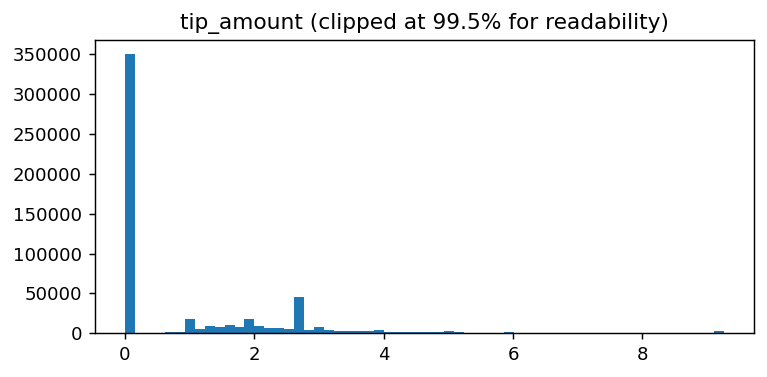

,n,mean_tip,median_tip,pct_zero_tip,pct_positive_tip,pct_missing_tip
payment_type,,,,,,
1.0,222303,2.188432,1.88,0.201959,0.798041,0.0
2.0,177652,0.000063,0.00,0.999972,0.000028,0.0
3.0,2274,-0.008030,0.00,0.989006,0.000880,0.0
4.0,709,0.000000,0.00,1.000000,0.000000,0.0
5.0,18,0.000000,0.00,1.000000,0.000000,0.0


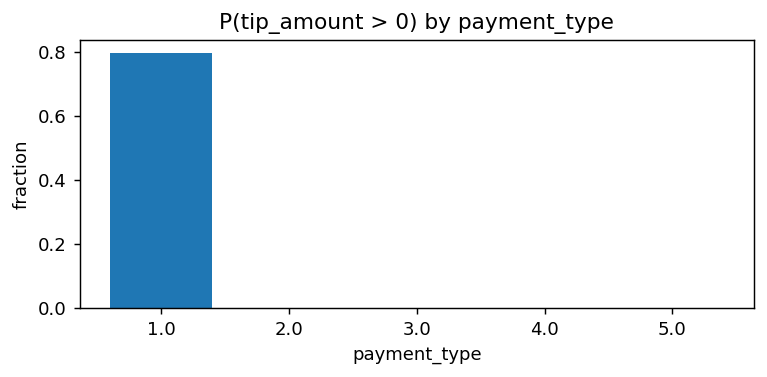

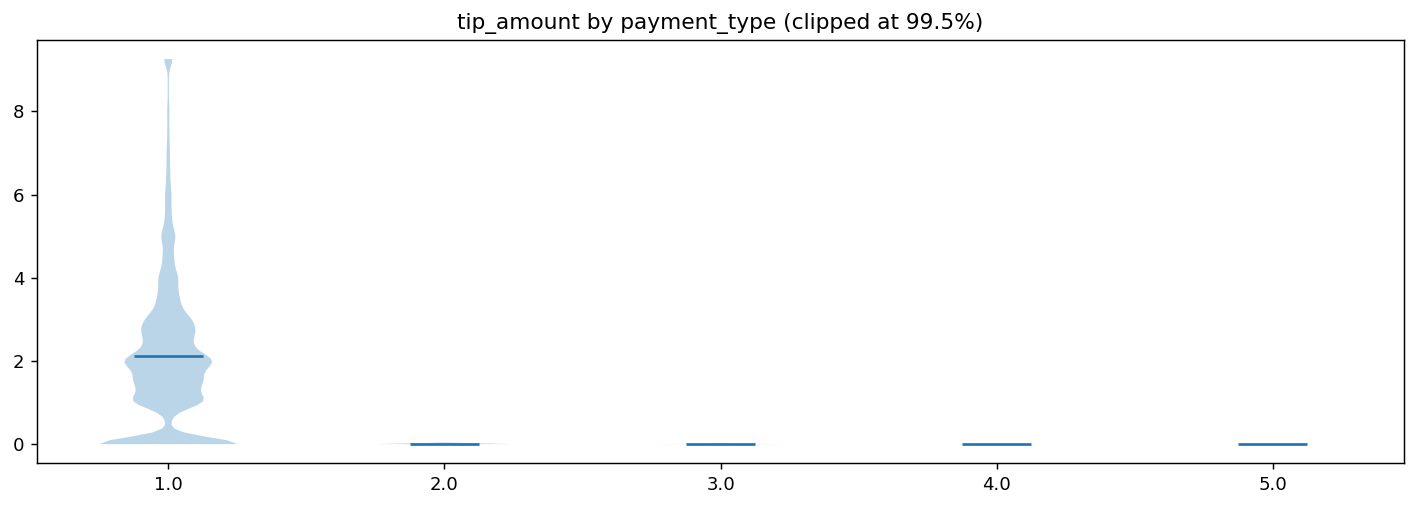

In [8]:
# --- Tip Amount EDA ---

df = data.copy()

# 0) Tip sanity: overall distribution
x = df["tip_amount"].dropna()
print("tip_amount: n =", len(x))
print(x.describe(percentiles=[.5, .9, .95, .99]))

plt.figure(figsize=(6, 3))
plt.hist(x.clip(lower=0, upper=x.quantile(0.995)), bins=60)
plt.title("tip_amount (clipped at 99.5% for readability)")
plt.tight_layout()
plt.show()

# 1) Do tips depend on payment type? (just look)
g = df.groupby("payment_type")["tip_amount"]

tip_by_pay = pd.DataFrame({
    "n": g.size(),
    "mean_tip": g.mean(),
    "median_tip": g.median(),
    "pct_zero_tip": g.apply(lambda s: (s.fillna(0) == 0).mean()),
    "pct_positive_tip": g.apply(lambda s: (s > 0).mean()),
    "pct_missing_tip": g.apply(lambda s: s.isna().mean()),
}).sort_index()

display(tip_by_pay)

# Visual: fraction of positive tips by payment type
plt.figure(figsize=(6, 3))
plt.bar(tip_by_pay.index.astype(str), tip_by_pay["pct_positive_tip"])
plt.title("P(tip_amount > 0) by payment_type")
plt.xlabel("payment_type")
plt.ylabel("fraction")
plt.tight_layout()
plt.show()

# Visual: tip distribution for each payment type (clipped)
pay_types = tip_by_pay.index.tolist()
clip_hi = df["tip_amount"].dropna().quantile(0.995)

plt.figure(figsize=(min(12, 2.2 * len(pay_types)), 4))
plt.violinplot(
    [df.loc[df["payment_type"] == pt, "tip_amount"].dropna().clip(0, clip_hi).values
     for pt in pay_types],
    showmeans=True,
    showextrema=False
)
plt.xticks(range(1, len(pay_types) + 1), [str(pt) for pt in pay_types])
plt.title("tip_amount by payment_type (clipped at 99.5%)")
plt.tight_layout()
plt.show()


In [9]:
# 3) For tip modeling: keep credit-card payments only
df_cc = df[df["payment_type"] == 1].copy()

print(
    "Rows total:", len(df),
    "| credit-card only:", len(df_cc)
)

Rows total: 564477 | credit-card only: 222303


,corr,abs_corr
total_amount,0.452404,0.452404
trip_distance,0.263159,0.263159
fare_amount,0.229825,0.229825
congestion_surcharge,0.225001,0.225001
tolls_amount,0.093439,0.093439
VendorID,0.090814,0.090814
DOLocationID,0.081046,0.081046
extra,0.080776,0.080776
RatecodeID,0.038463,0.038463
duration_min,0.029485,0.029485


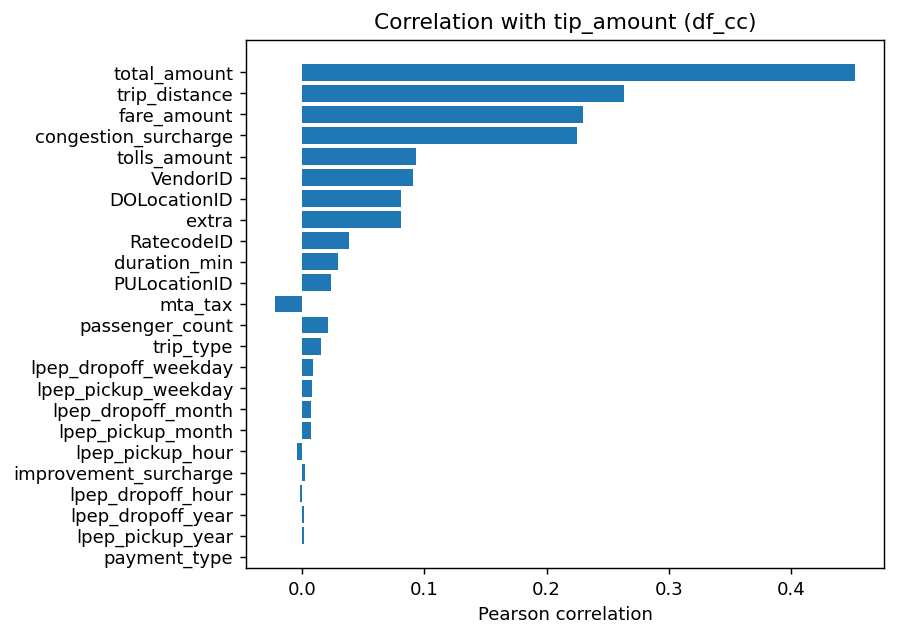

In [10]:
# numeric-only correlations on df_cc
num = df_cc.select_dtypes(include=[np.number])

# correlations with tip_amount
corr = num.corr(numeric_only=True)["tip_amount"].drop("tip_amount")

tip_corr = (
    corr.to_frame("corr")
        .assign(abs_corr=lambda t: t["corr"].abs())
        .sort_values("abs_corr", ascending=False)
)

display(tip_corr)

plt.figure(figsize=(7, 5))
plt.barh(tip_corr.index[::-1], tip_corr["corr"][::-1])
plt.title(f"Correlation with tip_amount (df_cc)")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 4) Pandemic shift over time
Monthly **trip volume** and **total paid** (Jan vs Apr vs Aug 2020).

In [11]:
pickup_col = "lpep_pickup_datetime"
data["pickup_dt"] = pd.to_datetime(data[pickup_col], errors="coerce")
data["pickup_date"] = data["pickup_dt"].dt.date

ts_month = data.groupby("month").agg(
    trips=("pickup_dt","count"),
    total_pay=("total_amount","sum"),
    mean_fare=("fare_amount","mean")
).sort_index()

ts_month


,trips,total_pay,mean_fare
month,,,
01,447770,8462225.91,15.839504
04,35644,701850.27,16.594600
08,81063,2001414.84,21.229762


Year counts:


pickup_dt
2020    564441
2019        19
2009        13
2010         3
2008         1
Name: count, dtype: int64

Month counts (dominant year only):


pickup_dt
1    447717
2        22
3         1
4     35638
7         2
8     81060
9         1
Name: count, dtype: int64

Keeping months with >= 1000 rides:


pickup_dt
1    447717
4     35638
8     81060
Name: count, dtype: int64

Months in filtered df: ['01', '04', '08']


,month,day,trips,mean_fare,mean_pax,frac_cc,frac_cash
0,01,1,10970,16.247980,1.354857,0.404011,0.392252
1,01,2,15023,17.041944,1.307822,0.318179,0.308394
2,01,3,16062,16.227897,1.302862,0.345287,0.310920
3,01,4,14295,15.351226,1.307194,0.369150,0.370059
4,01,5,12732,15.685035,1.311771,0.352183,0.308828


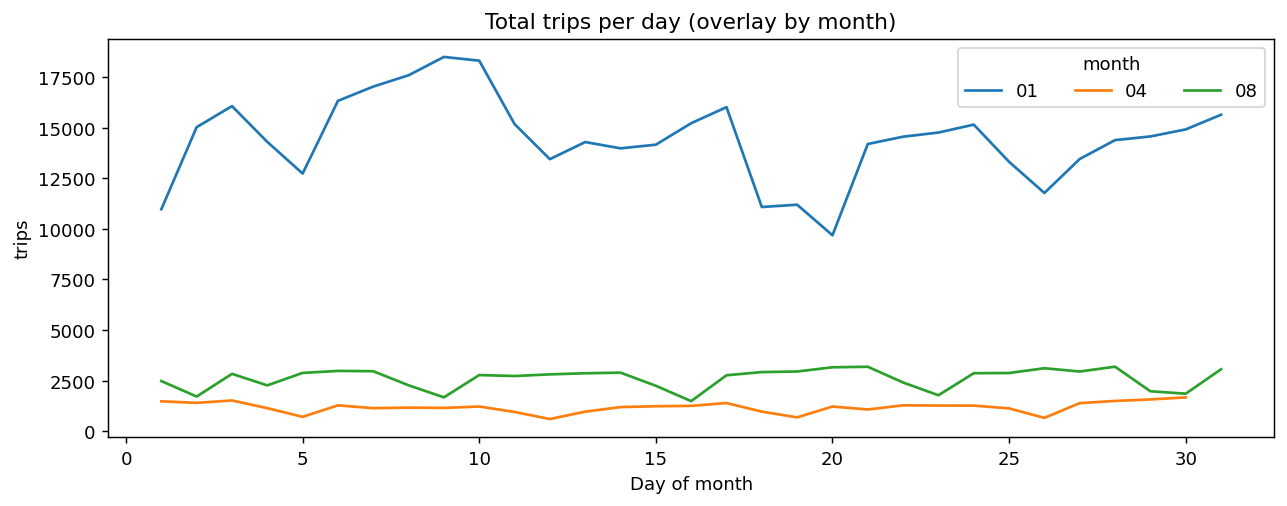

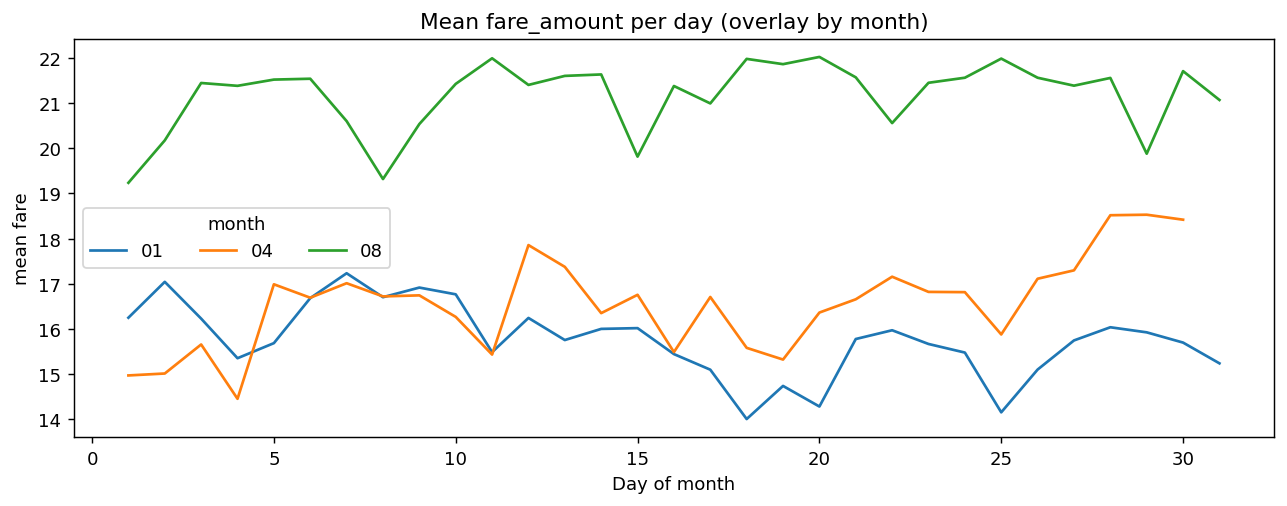

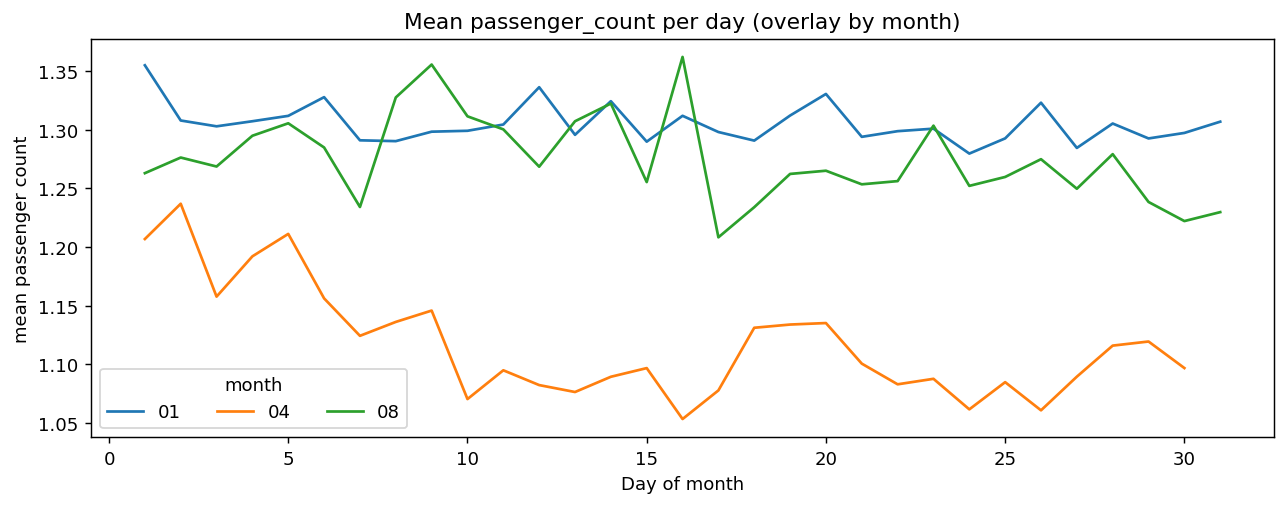

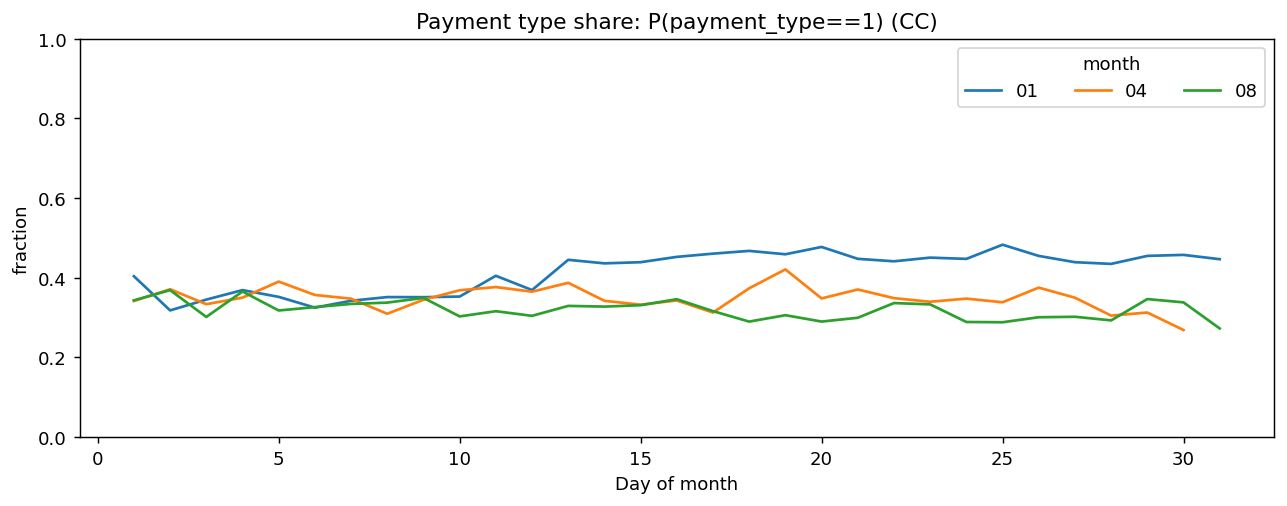

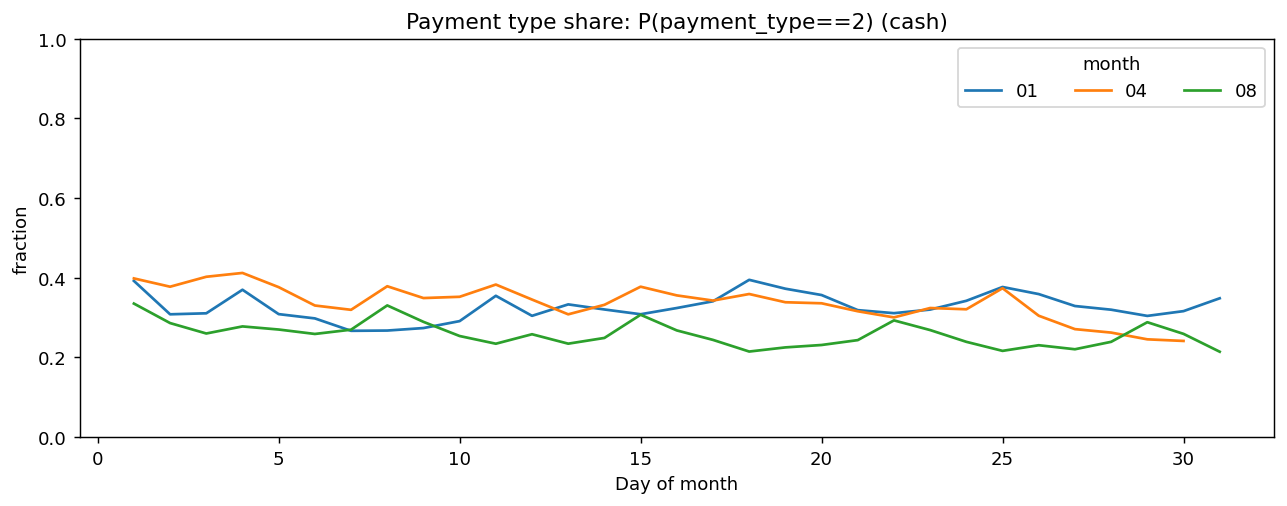

In [12]:
# --- Time-series EDA: year + month hygiene (concise) ---
pickup_col = "lpep_pickup_datetime"

# keep only the dominant year
year_counts = data["pickup_dt"].dt.year.value_counts(dropna=True)
main_year = year_counts.index[0]
df = data[data["pickup_dt"].dt.year == main_year].copy()

print("Year counts:")
display(year_counts)

# month counts within dominant year
month_counts = df["pickup_dt"].dt.month.value_counts().sort_index()
print("Month counts (dominant year only):")
display(month_counts)

# filter months with enough volume
min_rides = 1000
keep_months = month_counts[month_counts >= min_rides].index
df = df[df["pickup_dt"].dt.month.isin(keep_months)]

print(f"Keeping months with >= {min_rides} rides:")
display(month_counts.loc[keep_months])

# month label + day-of-month axis
df["month"] = df["pickup_dt"].dt.strftime("%m")   # '01', '04', '08' like your table
df["day"] = df["pickup_dt"].dt.day


months = sorted(df["month"].unique().tolist())
print("Months in filtered df:", months)

# daily aggregates per month, aligned by day-of-month
daily = (
    df.groupby(["month", "day"])
        .agg(
            trips=("pickup_dt", "count"),
            mean_fare=("fare_amount", "mean"),
            mean_pax=("passenger_count", "mean"),
            frac_cc=("payment_type", lambda s: (s == 1).mean()),
            frac_cash=("payment_type", lambda s: (s == 2).mean()),
        )
        .reset_index()
)

display(daily.head())

def overlay(value_col, title, ylabel, ylim=None):
    plt.figure(figsize=(10, 4))
    for m in months:
        s = daily.loc[daily["month"] == m].sort_values("day")
        plt.plot(s["day"], s[value_col], label=m)
    plt.title(title)
    plt.xlabel("Day of month")
    plt.ylabel(ylabel)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend(title="month", ncol=3)
    plt.tight_layout()
    plt.show()

overlay("trips",     "Total trips per day (overlay by month)",           "trips")
overlay("mean_fare", "Mean fare_amount per day (overlay by month)",      "mean fare")
overlay("mean_pax",  "Mean passenger_count per day (overlay by month)",  "mean passenger count")
overlay("frac_cc",   "Payment type share: P(payment_type==1) (CC)",      "fraction", ylim=(0, 1))
overlay("frac_cash", "Payment type share: P(payment_type==2) (cash)",    "fraction", ylim=(0, 1))


## 5) Geography by zone
The notebook now looks for zone metadata under `TLC_data/`.
- The bundled geojson is enough for choropleths.
- `taxi_zone_lookup.csv` is optional; if it is missing we derive a simple lookup table from the geojson properties.
- If `geopandas` is not installed, the choropleth cell will print install guidance instead of crashing.


In [13]:
zones = None

if ZONE_LOOKUP and ZONE_LOOKUP.exists():
    zones = pd.read_csv(ZONE_LOOKUP)
elif ZONES_GEOJSON and ZONES_GEOJSON.exists():
    import json

    raw_geo = json.loads(ZONES_GEOJSON.read_text(encoding="utf-8"))
    rows = [feat.get("properties", {}) for feat in raw_geo.get("features", [])]
    zones = pd.DataFrame(rows).rename(
        columns={"locationid": "LocationID", "zone": "Zone", "borough": "Borough"}
    )
    if "LocationID" in zones.columns:
        zones["LocationID"] = pd.to_numeric(zones["LocationID"], errors="coerce").astype("Int64")
    keep_cols = [c for c in ["LocationID", "Zone", "Borough"] if c in zones.columns]
    zones = zones[keep_cols].drop_duplicates().sort_values(keep_cols)

if zones is None or zones.empty:
    print("No zone lookup metadata found under TLC_data/.")
else:
    zones.head()


In [14]:
# --- Choropleths by month (using df from time-series EDA) ---
try:
    import geopandas as gpd
except ImportError:
    gpd = None
    print("Install geopandas for choropleths: conda install -c conda-forge geopandas")

if gpd is None:
    pass
elif not ZONES_GEOJSON or not ZONES_GEOJSON.exists():
    print("No zone geojson found under TLC_data/.")
elif "df" not in globals() or "months" not in globals():
    print("Run the time-series EDA cell above first so df and months are defined.")
else:
    g = gpd.read_file(ZONES_GEOJSON)
    g = g.rename(columns={"locationid": "LocationID", "zone": "Zone", "borough": "Borough"})
    g["LocationID"] = pd.to_numeric(g["LocationID"], errors="coerce").astype("Int64")
    g = g.dropna(subset=["LocationID"]).copy()
    g["LocationID"] = g["LocationID"].astype(int)

    for m in months:
        d = df[df["month"] == m]

        pu = (
            d["PULocationID"].value_counts()
              .rename("pu_count")
              .reset_index()
              .rename(columns={"PULocationID": "LocationID"})
        )
        do = (
            d["DOLocationID"].value_counts()
              .rename("do_count")
              .reset_index()
              .rename(columns={"DOLocationID": "LocationID"})
        )

        gg = (
            g.merge(pu, on="LocationID", how="left")
             .merge(do, on="LocationID", how="left")
             .fillna({"pu_count": 0, "do_count": 0})
        )

        ax = gg.plot(column="pu_count", legend=True, figsize=(8, 8))
        ax.set_title(f"Pickup intensity by zone - month {m}")
        ax.set_axis_off()
        plt.show()

        ax = gg.plot(column="do_count", legend=True, figsize=(8, 8))
        ax.set_title(f"Dropoff intensity by zone - month {m}")
        ax.set_axis_off()
        plt.show()


Install geopandas for choropleths: conda install -c conda-forge geopandas


## 6) Basic tip regression (credit card only)
Target: `tip_amount`. Filter: `payment_type == 1`.

In [15]:
# --- Regress tip_amount against ALL numeric features (df_cc) ---
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

dfm = df_cc.copy()


# all numeric features except target
num = dfm.select_dtypes(include=[np.number])
X = num.drop(columns=["tip_amount"])
y = dfm["tip_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("ridge", Ridge(alpha=1.0)),
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("ALL-NUMERIC RIDGE")
print("X shape:", X.shape)
print("R2:", r2, " RMSE:", rmse)


ALL-NUMERIC RIDGE
X shape: (222303, 24)
R2: 0.9859519416202386  RMSE: 0.39535240528736737


Perfect fit becuase:

$tip\approx total-(fare+surcharges+tolls+...)$

In [16]:
ridge = model.named_steps["ridge"]

coef = pd.Series(ridge.coef_, index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False)
display(coef.head(25))

print("intercept:", ridge.intercept_)

mta_tax                 -1.023046
improvement_surcharge   -1.015975
fare_amount             -0.978999
tolls_amount            -0.978529
total_amount             0.977978
congestion_surcharge    -0.898778
trip_type                0.445517
extra                   -0.424031
VendorID                -0.319693
RatecodeID              -0.056839
lpep_pickup_year         0.019699
lpep_pickup_month        0.019047
lpep_pickup_weekday      0.018550
lpep_pickup_hour        -0.012789
lpep_dropoff_month      -0.010962
trip_distance            0.006297
lpep_dropoff_year       -0.004519
lpep_dropoff_hour       -0.002272
passenger_count          0.001464
PULocationID            -0.000190
DOLocationID             0.000050
lpep_dropoff_weekday    -0.000044
duration_min            -0.000011
payment_type             0.000000
dtype: float64

intercept: -30.482335800465183


In [17]:
# --- DecisionTreeRegressor baseline NO LEAKAGE ---
from sklearn.tree import DecisionTreeRegressor

num = dfm.select_dtypes(include=[np.number])
X = num.drop(columns=["tip_amount", "total_amount"])
y = dfm["tip_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

tree = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=200,
        random_state=0
    )),
])

tree.fit(X_train, y_train)
pred = tree.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("TREE")
print("R2:", r2, " RMSE:", rmse)


TREE
R2: 0.16994275435613238  RMSE: 3.0389968933846037


In [18]:
# --- Temporal split (train Jan, test Apr) ---

num = dfm.select_dtypes(include=[np.number])

# split by month (assumes dfm["month"] exists, e.g. "01", "04")
train_idx = dfm["month"] == "01"
test_idx  = dfm["month"] == "04"

X_train = num.loc[train_idx].drop(columns=["tip_amount", "total_amount"])
y_train = dfm.loc[train_idx, "tip_amount"]

X_test  = num.loc[test_idx].drop(columns=["tip_amount", "total_amount"])
y_test  = dfm.loc[test_idx, "tip_amount"]

tree = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=200,
        random_state=0
    )),
])

tree.fit(X_train, y_train)
pred = tree.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("TREE - train Jan, test Apr")
print("Train n:", train_idx.sum(), " Test n:", test_idx.sum())
print("R2:", r2, " RMSE:", rmse)


TREE - train Jan, test Apr
Train n: 184404  Test n: 12274
R2: 0.12235659371146257  RMSE: 2.855542591806024
